# SymPyによる解析力学

## 概要
物理学、特に力学の世界において、ニュートンの運動方程式 $F=ma$ は直感的で強力であるが、複雑な拘束条件を持つ系（例えば、動く台車に吊るされた振り子など）を扱う場合、力のベクトルを全て書き下すのは非常に骨が折れる作業となる。



そこで登場するのが「解析力学（ラグランジュ形式）」である。この体系では、エネルギーというスカラー量に着目し、統一的な手続きで運動方程式を導出できる。しかし、その計算過程（偏微分や時間微分）は手計算では繁雑になりがちである。

本記事では、Pythonの数式処理ライブラリ **SymPy** を用いて、ラグランジュ形式による運動方程式の導出を記号的に行う方法を解説する。具体的には、以下のステップを詳細に追う。

1. **ラグランジュ形式の基礎**：オイラー・ラグランジュ方程式
2. **単振り子**：非線形微分方程式の導出
3. **二重振り子（あるいは動く台車上の振り子）**：連成系の解析

### 筆者の環境
筆者の実行環境は以下の通りである。

In [1]:
!sw_vers

ProductName:		macOS
ProductVersion:		15.5
BuildVersion:		24F74


In [2]:
!python -V

Python 3.12.12


必要なライブラリをインポートする。物理変数は時間 $t$ の関数として定義するため、`Function` や `dynamicsymbols` が役立つが、ここでは基礎的な `symbols` と `Function` を組み合わせて明示的に記述する。

In [3]:
import sympy
from sympy import symbols, Function, diff, sin, cos, simplify, Matrix, solve, Eq, S
from sympy.abc import t # 時間変数
from pprint import pprint as py_pprint

# 数式をLaTeX形式で綺麗に表示するための設定
sympy.init_printing()

print("sympy version :", sympy.__version__)

sympy version : 1.14.0


## 1. ラグランジュ形式の基礎

解析力学において、系の状態は一般化座標 $q_i(t)$ とその時間微分（一般化速度） $\dot{q}_i(t)$ で記述される。
ラグランジアン $L$ は、運動エネルギー $T$ とポテンシャルエネルギー $V$ の差として定義される。

$$ L(q, \dot{q}) = T - V $$

運動方程式は、以下の「オイラー・ラグランジュ方程式」によって与えられる。

$$ \frac{d}{dt} \left( \frac{\partial L}{\partial \dot{q}_i} \right) - \frac{\partial L}{\partial q_i} = 0 $$

この式をSymPyで計算する関数を定義しておこう。

In [4]:
def euler_lagrange(L, q, t):
    """
    ラグランジアン L と一般化座標 q からオイラー・ラグランジュ方程式を導出する関数
    """
    # qのドット（時間微分）
    q_dot = diff(q, t)

    # 1. L を q_dot で偏微分
    dL_dqdot = diff(L, q_dot)

    # 2. その結果を時間 t で微分
    # ここで注意：dL_dqdot は q(t) や q_dot(t) を含んでいるため、
    # 単純に diff(..., t) すると連鎖律が適用される。
    term1 = diff(dL_dqdot, t)

    # 3. L を q で偏微分
    dL_dq = diff(L, q)

    # 方程式: term1 - dL_dq = 0
    eq = Eq(term1 - dL_dq, 0)

    return eq

## 2. 単振り子：非線形微分方程式の導出

長さ $l$ の糸の先に質量 $m$ の重りがついた単振り子を考える。一般化座標として、鉛直方向からの角度 $\theta(t)$ を採用する。

### 2.1 座標と速度の定義

重りの位置 $(x, y)$ は以下のように表される（原点は支点、y軸は上向き正）。

$$ x = l \sin \theta, \quad y = -l \cos \theta $$

x方向の速度:


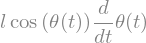

y方向の速度:


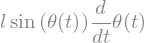

In [5]:
m, l, g = symbols('m l g', real=True, positive=True)
theta = Function('theta')(t)

x = l * sin(theta)
y = -l * cos(theta)

# 速度成分
vx = diff(x, t)
vy = diff(y, t)

print("x方向の速度:")
display(vx)
print("y方向の速度:")
display(vy)

### 2.2 ラグランジアンの構築

運動エネルギー $T$ とポテンシャルエネルギー $V$ を計算する。

$$ T = \frac{1}{2} m (\dot{x}^2 + \dot{y}^2) $$
$$ V = mgy $$

ラグランジアン L:


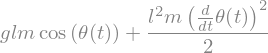

In [6]:
T = S(1)/2 * m * (vx**2 + vy**2)
V = m * g * y

# 簡約化（三角関数の恒等式 sin^2 + cos^2 = 1 が使われる）
T = simplify(T)

L = T - V

print("ラグランジアン L:")
display(L)

ラグランジアンは $L = 0.5 m l^2 \dot{\theta}^2 + m g l \cos(\theta)$ となった。

### 2.3 運動方程式の導出

先ほど定義した `euler_lagrange` 関数を用いて方程式を導く。

単振り子の運動方程式:


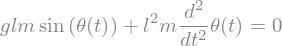

In [7]:
eq_pendulum = euler_lagrange(L, theta, t)

print("単振り子の運動方程式:")
display(eq_pendulum)

結果は $1.0 m l^2 \ddot{\theta} + m g l \sin(\theta) = 0$ となる。両辺を $ml^2$ で割れば、おなじみの式が得られる。

$$ \ddot{\theta} + \frac{g}{l} \sin \theta = 0 $$

SymPyを使えば、座標変換からエネルギー計算、微分の手続きまでを一貫して行えるため、計算ミスの心配がない。

## 3. 応用：動く台車上の振り子

次に、より複雑な系として「水平に動く台車（質量 $M$）に吊るされた振り子（質量 $m$, 長さ $l$）」を考える。これは制御工学のベンチマーク問題としても有名である。

一般化座標は、台車の水平位置 $x(t)$ と振り子の角度 $\theta(t)$ の2つである。

### 3.1 座標定義

台車の位置: $(x, 0)$
振り子の重りの位置: $(x + l \sin \theta, -l \cos \theta)$

振り子の速度（x成分）:


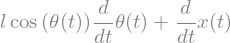

In [8]:
M = symbols('M', real=True, positive=True)
x_cart = Function('x')(t)

# 振り子の位置（台車の位置 x_cart が加算される）
x_pend = x_cart + l * sin(theta)
y_pend = -l * cos(theta)

# 速度
v_cart = diff(x_cart, t)
vx_pend = diff(x_pend, t)
vy_pend = diff(y_pend, t)

print("振り子の速度（x成分）:")
display(vx_pend)

### 3.2 ラグランジアンの構築

運動エネルギーは台車と振り子の和である。

$$ T = \frac{1}{2} M \dot{x}^2 + \frac{1}{2} m (\dot{x}_{pend}^2 + \dot{y}_{pend}^2) $$

ポテンシャルエネルギーは振り子のみが持つ（台車は水平運動なので一定）。

$$ V = m g y_{pend} $$

連成系のラグランジアン:


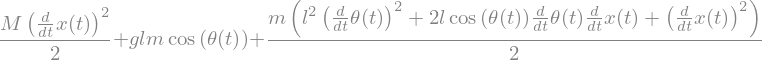

In [9]:
T_cart = S(1)/2 * M * v_cart**2
T_pend = S(1)/2 * m * (vx_pend**2 + vy_pend**2)

T_total = simplify(T_cart + T_pend)
V_total = m * g * y_pend

L_coupled = T_total - V_total

print("連成系のラグランジアン:")
display(L_coupled)

### 3.3 運動方程式の導出

変数 $x$ と $\theta$ それぞれについて、オイラー・ラグランジュ方程式を立てる。

台車の運動方程式:


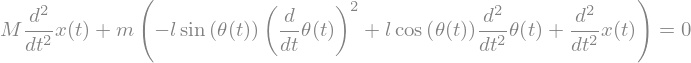


振り子の運動方程式:


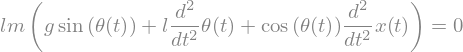

In [10]:
# x についての方程式
eq_x = euler_lagrange(L_coupled, x_cart, t)

# theta についての方程式
eq_theta = euler_lagrange(L_coupled, theta, t)

print("台車の運動方程式:")
display(simplify(eq_x))

print("\n振り子の運動方程式:")
display(simplify(eq_theta))

非常に複雑な連立微分方程式が導出された。台車の加速度 $\ddot{x}$ と振り子の角加速度 $\ddot{\theta}$ が互いの式に含まれており（連成）、相互作用していることがわかる。

手計算でこれを行うと、微分計算の過程で符号ミスや係数ミスが頻発するが、SymPyを用いれば一瞬で、かつ正確に結果を得ることができる。

## 結論

この記事では、SymPyを用いて解析力学の問題を解く方法を紹介した。

ラグランジュ形式は物理学において強力なツールであるが、その計算コストは高い。SymPyを活用することで、物理的なモデリング（$T$ と $V$ の定義）に集中し、機械的な微分計算はコンピュータに任せることができる。これは、より複雑なロボットアームの制御や、多体問題の解析において極めて有効なアプローチとなる。

### 参考文献
- [SymPy Documentation: Mechanics](https://docs.sympy.org/latest/modules/physics/mechanics/index.html) (SymPyには物理専用のモジュールもあるが、今回は基礎原理を理解するために汎用モジュールで実装した)